In [1]:
import shap
import pickle
import pandas as pd
from pathlib import Path


c:\Users\johann_bluhm\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


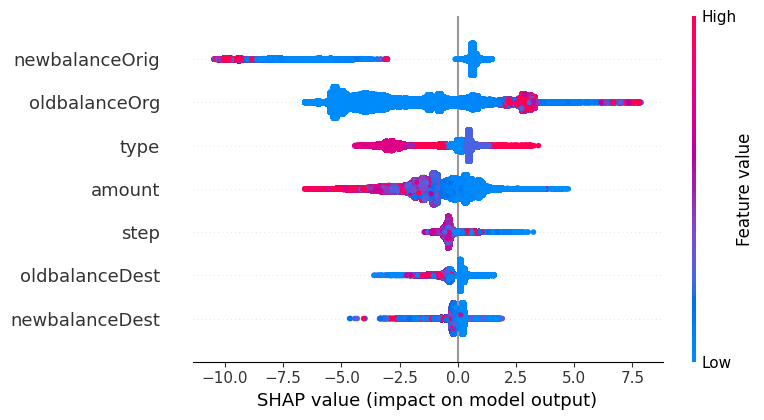

In [2]:
# Carregar o modelo treinado
base_dir = Path().resolve().parent
model_path = base_dir / "models" / "xgboost_fraud_model.pkl"
with open(model_path, 'rb') as f:
    model = pickle.load(f)

# Carregar uma amostra de teste (você pode exportar isso do preprocessing.py)
X_test = pd.read_csv(base_dir / "data" / "processed" / "X_test.csv")

# Criar o explicador SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Gerar o gráfico de impacto das variáveis
shap.summary_plot(shap_values, X_test)